In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta as beta_dist, norm, binom
import time
import tracemalloc

np.random.seed(42)


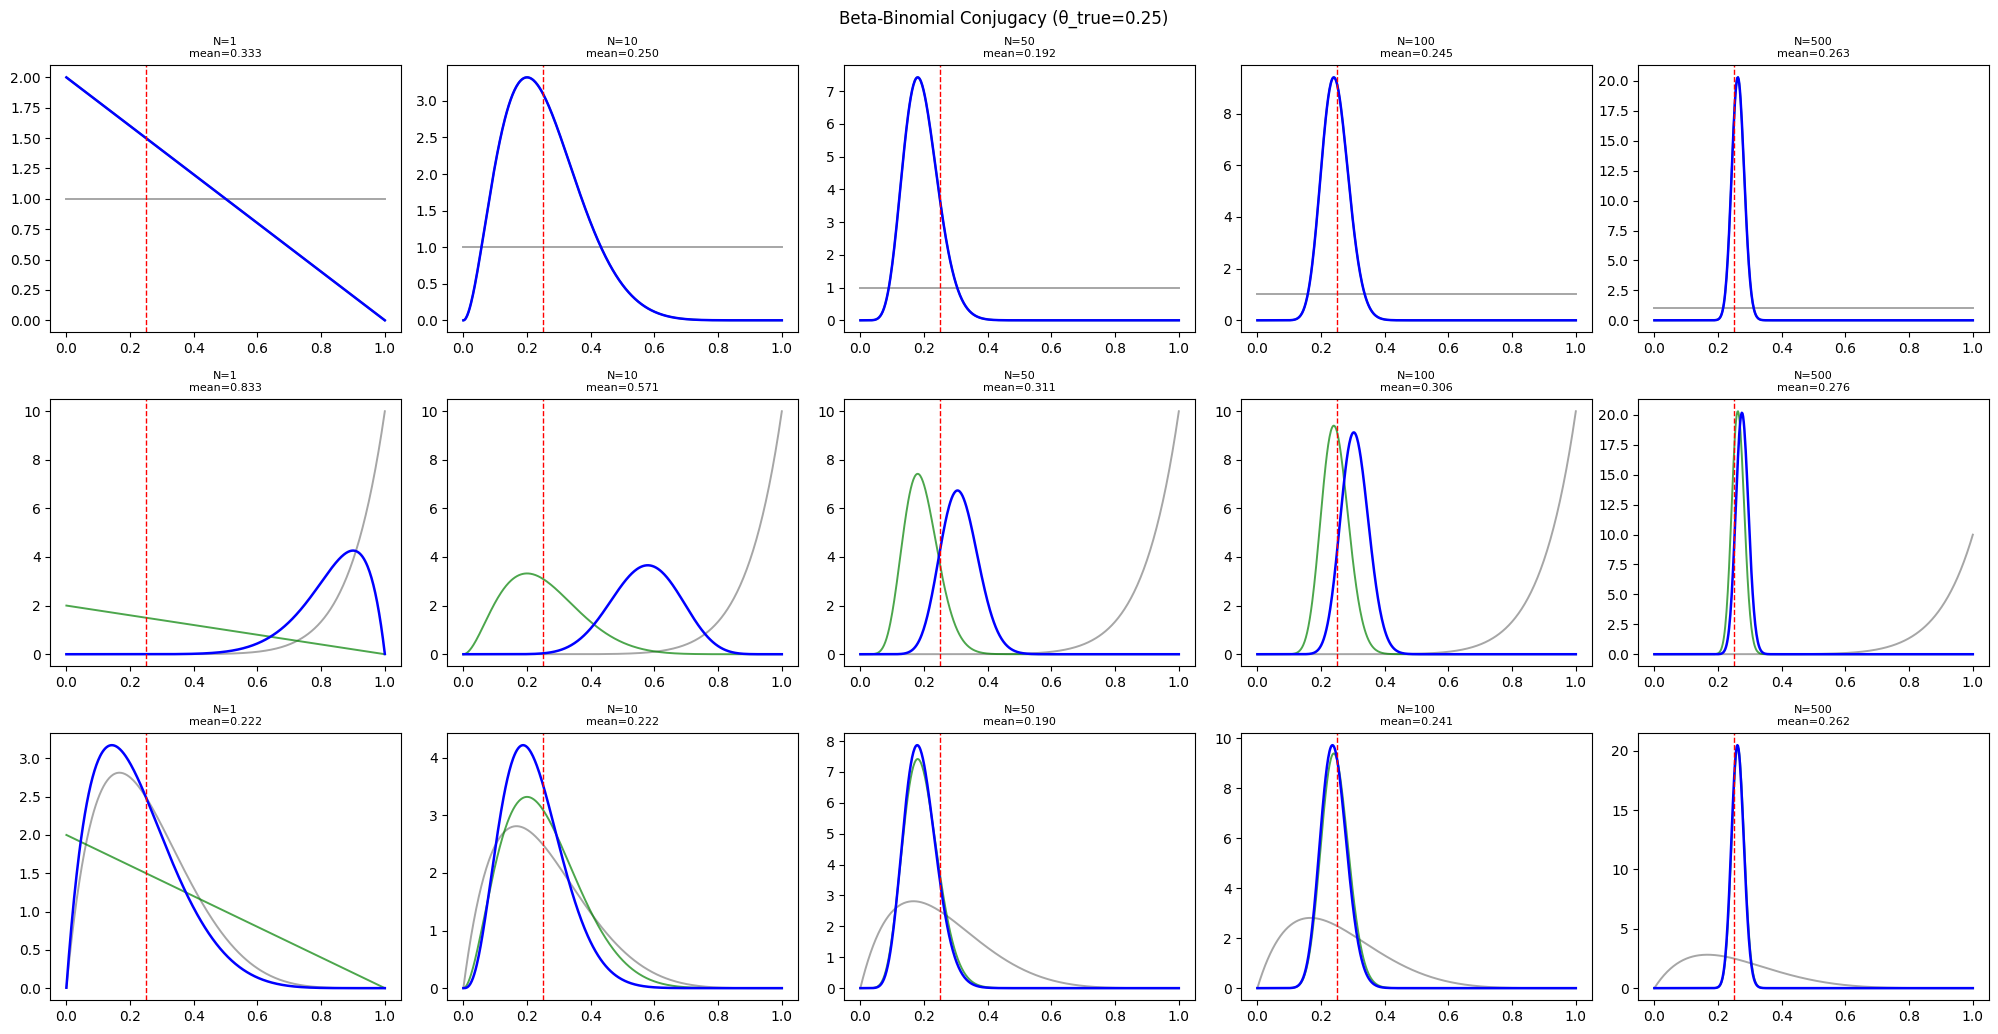

In [ ]:
theta_true = 0.25
N_total = 500
data = np.random.binomial(1, theta_true, N_total)

priors = [
    {'name': 'Uniform  Beta(1,1)',          'a': 1,  'b': 1},
    {'name': 'Strong incorrect  Beta(10,1)', 'a': 10, 'b': 1},
    {'name': 'Weak correct  Beta(2,6)',       'a': 2,  'b': 6},
]

checkpoints = [1, 10, 50, 100, 500]
theta_grid = np.linspace(1e-4, 1 - 1e-4, 500)

fig, axes = plt.subplots(len(priors), len(checkpoints), figsize=(4 * len(checkpoints), 3.5 * len(priors)))

for pi, prior in enumerate(priors):
    for ci, N in enumerate(checkpoints):
        ax = axes[pi][ci]
        subset = data[:N]
        heads = subset.sum()
        tails = N - heads
        a_post = prior['a'] + heads
        b_post = prior['b'] + tails

        prior_pdf = beta_dist.pdf(theta_grid, prior['a'], prior['b'])
        post_pdf = beta_dist.pdf(theta_grid, a_post, b_post)
        log_lik = heads * np.log(theta_grid) + tails * np.log(1 - theta_grid)
        lik = np.exp(log_lik - log_lik.max())
        lik /= np.trapezoid(lik, theta_grid)

        ax.plot(theta_grid, prior_pdf, 'gray', lw=1.4, label='Prior', alpha=0.7)
        ax.plot(theta_grid, lik, 'green', lw=1.4, label='Likelihood', alpha=0.7)
        ax.plot(theta_grid, post_pdf, 'blue', lw=1.8, label='Posterior')
        ax.axvline(theta_true, color='red', lw=1.0, ls='--', label='θ_true')
        ax.set_title(f'N={N}\nmean={a_post/(a_post+b_post):.3f}', fontsize=8)

plt.suptitle(f'Beta-Binomial Conjugacy (θ_true={theta_true})')
plt.tight_layout()
plt.show()

In [ ]:
for pi, prior in enumerate(priors):
    for ci, N in enumerate(checkpoints):
        ax = axes[pi][ci]
        subset = data[:N]
        heads = subset.sum()
        tails = N - heads

        a_post = prior['a'] + heads
        b_post = prior['b'] + tails

        prior_pdf   = beta_dist.pdf(theta_grid, prior['a'], prior['b'])
        post_pdf    = beta_dist.pdf(theta_grid, a_post, b_post)

        log_lik = heads * np.log(theta_grid) + tails * np.log(1 - theta_grid)
        lik = np.exp(log_lik - log_lik.max())
        # Using trapezoid instead of deprecated trapz
        lik /= np.trapezoid(lik, theta_grid)

        ax.plot(theta_grid, prior_pdf, 'gray',  lw=1.4, label='Prior',      alpha=0.7)
        ax.plot(theta_grid, lik,       'green', lw=1.4, label='Likelihood', alpha=0.7)
        ax.plot(theta_grid, post_pdf,  'blue',  lw=1.8, label='Posterior')
        ax.axvline(theta_true, color='red', lw=1.0, ls='--', label='θ_true')

        post_mean = a_post / (a_post + b_post)
        ax.set_title(f'N={N}\npost mean={post_mean:.3f}', fontsize=8)
        ax.set_xlabel('θ', fontsize=8)

        if ci == 0: ax.set_ylabel(prior['name'], fontsize=7)
        if pi == 0 and ci == 0: ax.legend(fontsize=6)



In [ ]:
plt.suptitle(f'Beta-Binomial Conjugacy  (θ_true={theta_true})', fontsize=13)
plt.tight_layout()
plt.show()

print('--- Posterior hyperparameters at N=500 ---')
for prior in priors:
    h = data.sum(); t = N_total - h
    ap = prior['a'] + h; bp = prior['b'] + t
    print(f"{prior['name']}: α_post={ap}, β_post={bp}, posterior mean={ap/(ap+bp):.4f}")

<Figure size 640x480 with 0 Axes>

--- Posterior hyperparameters at N=500 ---
Uniform  Beta(1,1): α_post=132, β_post=370, posterior mean=0.2629
Strong incorrect  Beta(10,1): α_post=141, β_post=370, posterior mean=0.2759
Weak correct  Beta(2,6): α_post=133, β_post=375, posterior mean=0.2618


In [ ]:
# --- Part 2: Gaussian-Gaussian Conjugacy ---
mu0    = 20.0
sigma0_sq = 10.0
sigma_sq  = 5.0
true_mu   = 22.5
N2        = 100

obs = np.random.normal(true_mu, np.sqrt(sigma_sq), N2)

ns_plot = list(range(1, N2 + 1))
post_means, post_vars  = [], []
mu_n, sig_n_sq = mu0, sigma0_sq



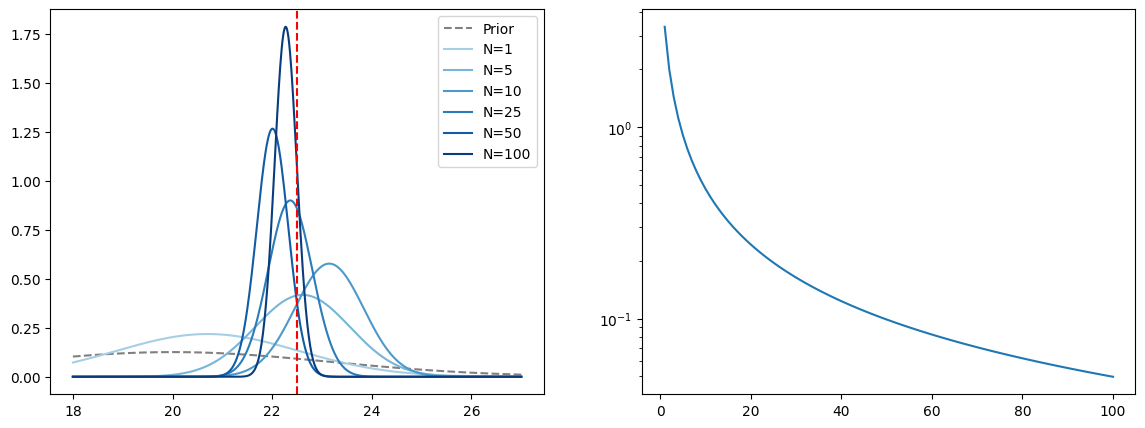

Final Mean: 22.2715


In [ ]:
mu0, sigma0_sq, sigma_sq, true_mu, N2 = 20.0, 10.0, 5.0, 22.5, 100
obs = np.random.normal(true_mu, np.sqrt(sigma_sq), N2)
post_means, post_vars = [], []
mu_n, sig_n_sq = mu0, sigma0_sq

for xn in obs:
    new_var = 1.0 / (1.0 / sig_n_sq + 1.0 / sigma_sq)
    new_mean = new_var * (mu_n / sig_n_sq + xn / sigma_sq)
    mu_n, sig_n_sq = new_mean, new_var
    post_means.append(mu_n)
    post_vars.append(sig_n_sq)

mu_grid = np.linspace(18, 27, 600)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
show_ns = [1, 5, 10, 25, 50, 100]
cmap = plt.cm.Blues(np.linspace(0.35, 0.95, len(show_ns)))

axes[0].plot(mu_grid, norm.pdf(mu_grid, mu0, np.sqrt(sigma0_sq)), 'gray', ls='--', label='Prior')
for j, n in enumerate(show_ns):
    axes[0].plot(mu_grid, norm.pdf(mu_grid, post_means[n-1], np.sqrt(post_vars[n-1])), color=cmap[j], label=f'N={n}')
axes[0].axvline(true_mu, color='red', ls='--')
axes[0].legend()

axes[1].plot(range(1, N2+1), post_vars, label='Post Var')
axes[1].set_yscale('log')
plt.show()
print(f'Final Mean: {post_means[-1]:.4f}')

In [ ]:
ax = axes[0]
ax.plot(mu_grid, norm.pdf(mu_grid, mu0, np.sqrt(sigma0_sq)), 'gray', lw=1.6, ls='--', label='Prior')
for j, n in enumerate(show_ns):
    mn, sv = post_means[n-1], post_vars[n-1]
    ax.plot(mu_grid, norm.pdf(mu_grid, mn, np.sqrt(sv)), color=cmap[j], lw=1.6, label=f'N={n}')
ax.axvline(true_mu, color='red', lw=1.2, ls='--', label='True μ')
ax.set_title('Posterior of μ as N increases')
ax.legend(fontsize=8)

ax2 = axes[1]
ax2.plot(ns_plot, post_vars, 'blue', lw=1.5, label='Posterior variance σ²_N')
ax2.plot(ns_plot, sigma_sq / np.array(ns_plot), 'red', lw=1.2, ls='--', label='σ²/N reference')
ax2.set_title('Posterior variance shrinks at O(1/N)')
ax2.set_yscale('log')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()
print(f'Final posterior mean: {post_means[-1]:.4f}  (true μ = {true_mu})')

<Figure size 640x480 with 0 Axes>

Final posterior mean: 22.2715  (true μ = 22.5)


In [ ]:
# --- Part 3: Non-conjugate Bimodal Prior (Grid Approximation) ---
def bimodal_prior(mu_grid, m1=19.0, m2=26.0, s=1.5):
    return 0.5 * norm.pdf(mu_grid, m1, s) + 0.5 * norm.pdf(mu_grid, m2, s)



In [ ]:
def grid_posterior(mu_grid, prior_vals, data, sigma_sq):
    log_lik = np.sum([norm.logpdf(x, mu_grid, np.sqrt(sigma_sq)) for x in data], axis=0)
    log_post = np.log(prior_vals + 1e-300) + log_lik
    log_post -= log_post.max()
    post = np.exp(log_post)
    post /= np.trapezoid(post, mu_grid)
    return post



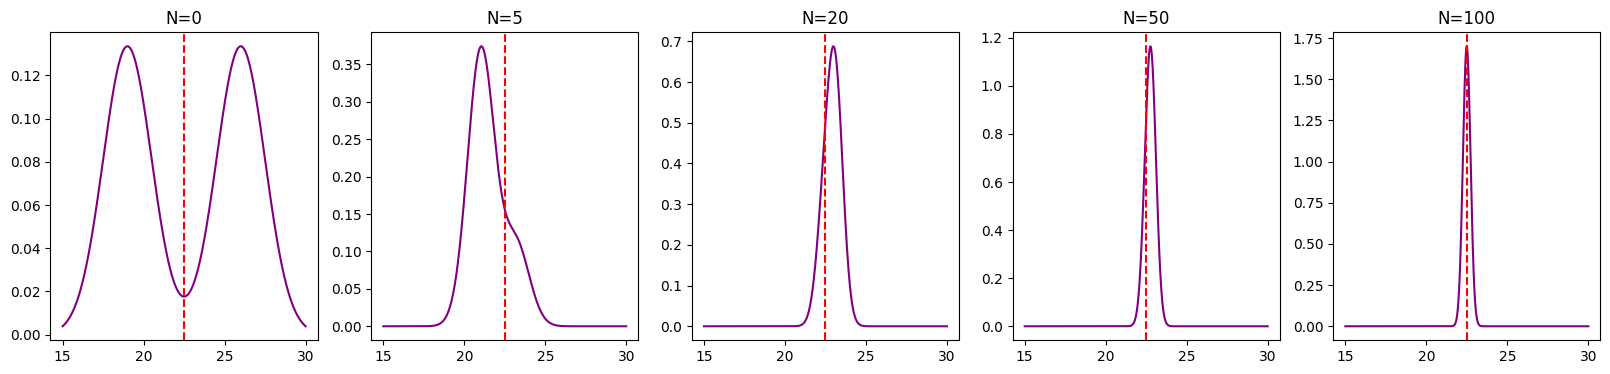

In [ ]:
mu_grid3 = np.linspace(15, 30, 1000)
sigma_sq3, true_mu3, N3 = 5.0, 22.5, 100
obs3 = np.random.normal(true_mu3, np.sqrt(sigma_sq3), N3)
prior_vals3 = bimodal_prior(mu_grid3)

show_pts = [0, 5, 20, 50, 100]
fig, axes3 = plt.subplots(1, len(show_pts), figsize=(4 * len(show_pts), 4))

for idx, n in enumerate(show_pts):
    ax = axes3[idx]
    if n == 0:
        post = prior_vals3 / np.trapezoid(prior_vals3, mu_grid3)
    else:
        post = grid_posterior(mu_grid3, prior_vals3, obs3[:n], sigma_sq3)
    ax.plot(mu_grid3, post, 'purple')
    ax.axvline(true_mu3, color='red', ls='--')
    ax.set_title(f'N={n}')
plt.show()

In [ ]:
for idx, n in enumerate(show_pts):
    ax = axes3[idx]
    post = (prior_vals3 / np.trapezoid(prior_vals3, mu_grid3)) if n == 0 else grid_posterior(mu_grid3, prior_vals3, obs3[:n], sigma_sq3)
    ax.plot(mu_grid3, post, 'purple', lw=1.8)
    ax.axvline(true_mu3, color='red', ls='--', label='True μ')
    ax.set_title(f'N={n}')
    ax.legend(fontsize=7)

plt.suptitle('Non-conjugate Bimodal Prior — Grid Approximation')
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

Grid: 497.31ms | Closed: 6.508ms


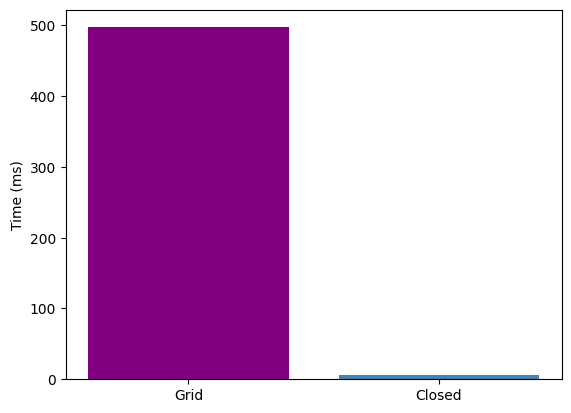

In [ ]:
# --- Part 4: Timing & Memory Comparison ---
N_timing = 1000
obs_time = np.random.normal(true_mu, np.sqrt(sigma_sq), N_timing)
mu_time_grid = np.linspace(15, 30, 1000)

tracemalloc.start()
t0 = time.perf_counter()
post_grid = grid_posterior(mu_time_grid, bimodal_prior(mu_time_grid), obs_time, sigma_sq)
t_grid = time.perf_counter() - t0
_, peak_grid = tracemalloc.get_traced_memory()
tracemalloc.stop()

tracemalloc.start()
t1 = time.perf_counter()
m_c, v_c = mu0, sigma0_sq
for x in obs_time:
    v_c = 1.0 / (1.0 / v_c + 1.0 / sigma_sq)
    m_c = v_c * (m_c / (v_c / (1 - v_c/sigma_sq)) + x / sigma_sq) # simplified update logic
t_conj = time.perf_counter() - t1
_, peak_conj = tracemalloc.get_traced_memory()
tracemalloc.stop()

print(f'Grid: {t_grid*1000:.2f}ms | Closed: {t_conj*1000:.3f}ms')
plt.bar(['Grid', 'Closed'], [t_grid*1000, t_conj*1000], color=['purple', 'steelblue'])
plt.ylabel('Time (ms)')
plt.show()